### BUSINESS UNDERSTANDING   

**What makes customers churn?**    
The problem is how to identify at an early stage the customers who are likely to churn so that proactive measures can be implemented to prevent these customers from leaving.
      
We would like to predict whether a customer will churn or not churn based on certain customer attributes like customer satisfaction scores, how long the customer has been with the company, payment failures, customer location, customer engagement level and the contract type.

It is critical to find the reasons why customers stop using the company's products. When these factors are known, the customers who are likely to churn can be identified early enough and special programs can be implemented to prevent these customers from churning. In this way, the company's continued profitability is assured.

Customer retention makes a lot of business sense - it costs around five (5) times more to acquire new customers than to retain existing customers. A reduction in customer churn can significantly increase revenue. The reasons for customer churn and who are these customers can be predicted before churn happens.

Engaging with unhappy customers, resolving issues and building stronger relationships directly impact customer retention.

Success can be measured in terms of a reduction in churn rate. Also, a Profit/Loss analysis is made by considering the increase in revenue against the money spent for customer retention.

The models that are produced can be used by marketing teams for retention campaigns, by customer support teams for proactive outreach, and by product teams for feature improvements. Leadership can also be guided by the model for churn strategy and forecasting.

**Import the required libraries**

In [67]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import math
import warnings
warnings.filterwarnings('ignore')

### DATA UNDERSTANDING

The Customer Churn Prediction Business Dataset comes from Kaggle.
This dataset is synthetically generated for educational, research, and portfolio purposes. While it reflects realistic business patterns, it does not represent real customer data.  

The less obvious meaning of some features in the data are as follows:     **'csat_score'** is Customer Satisfaction Score that measures short-term happiness with a specific event. **'nps_score'** is Net Promoter Score that measures long term loyalty.
**'email_open_rate'** indicates if customers find subject lines and sender information compelling enough to open the mail. Declining rates of these features predict disinterest and potential churn. High open rates suggest relevance and connection, while low rates flag a need to improve content, segmentation or timing to prevent users from becoming disengaged and leaving.

**Size of dataset**  
The original dataset has 32 columns and 10,000 rows.

**Missing Values**  
Only one column has missing values - **'complaint_type'** with 2,045 total missing values.

**Dropped Columns**  
The column **'customer_id'** is dropped because it contains unique values that will not affect the performance of the prediction model.

**Duplicate Rows**           
There are no duplicate rows.

**Imbalanced Data**           
The imbalanced data is addressed by using the parameter class_weight='balanced' and the technique called SMOTE-NC. The imbalanced data is typical of customer churn datasets (90% non-churn and 10% churn in this case).

In [68]:
# Load the dataset
df = pd.read_csv('customer_churn_business_dataset.csv')

In [69]:
# Check the number of rows and columns
df.shape

(10000, 32)

In [70]:
# Examine the dataset
df.head()

,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,...,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,...,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0


In [71]:
# Confirm the number of columns and rows, check for any missing values and verify data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             10000 non-null  object 
 1   gender                  10000 non-null  object 
 2   age                     10000 non-null  int64  
 3   country                 10000 non-null  object 
 4   city                    10000 non-null  object 
 5   customer_segment        10000 non-null  object 
 6   tenure_months           10000 non-null  int64  
 7   signup_channel          10000 non-null  object 
 8   contract_type           10000 non-null  object 
 9   monthly_logins          10000 non-null  int64  
 10  weekly_active_days      10000 non-null  int64  
 11  avg_session_time        10000 non-null  float64
 12  features_used           10000 non-null  int64  
 13  usage_growth_rate       10000 non-null  float64
 14  last_login_days_ago     10000 non-null 

**Missing Values**    
Only one column has missing values - **complaint_type**

In [72]:
# Verify the total missing values
total_missing_values = df.isnull().sum().sum()  # count the total number of missing values

print(f'There are {total_missing_values} total missing values.')

There are 2045 total missing values.


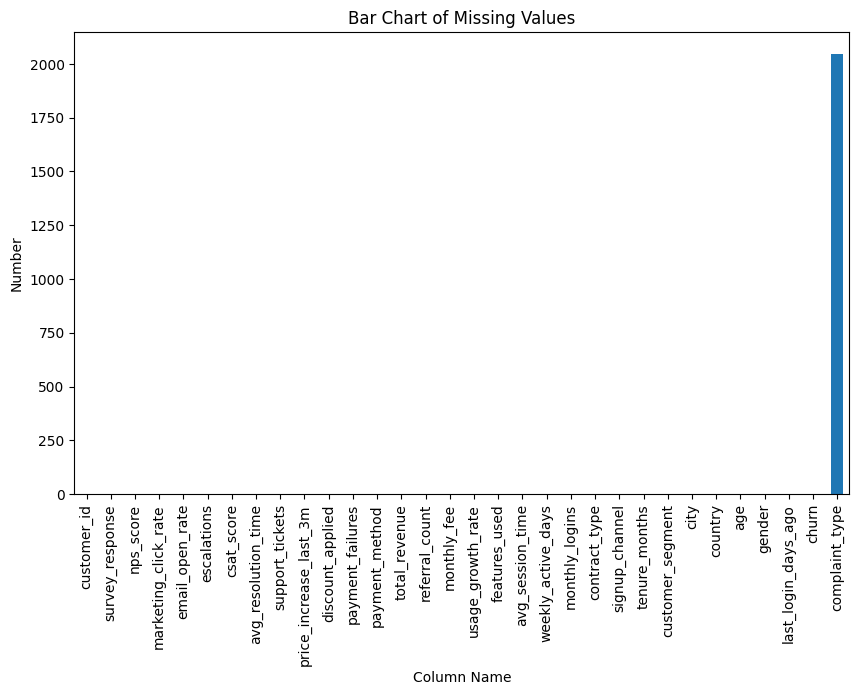

In [73]:
# Display the bar chart of missing values
plt.figure(figsize=(10,6))
df.isnull().sum().sort_values().plot(kind='bar')
plt.title('Bar Chart of Missing Values')
plt.xlabel('Column Name')
plt.ylabel('Number')
plt.show()

In [74]:
# Confirm the column with missing values
column_missing_values = df.columns[df.isnull().any()].tolist()
column_missing_values

['complaint_type']

**Descriptive Statistical Analysis of numerical features**     
**age** and **tenure_months** are roughly spread uniformly. **monthly_logins** are right skewed - most are in the low side. **weekly_active_days** are fairly distributed. **avg_session_time** and **features_used** are slightly right skewed. Distribution is almost normal for **usage_growth_rate** and centered at zero. Declining rate is a churn risk. **last_login_days_ago** is strongly skewed right with most logging in recently but there are cases on the high side. **monthly_fee** is mostly on the low side. **total_revenue** is right skewed and there are many low tenure customers and few long tenure customers. The number of **payment_failures** is low. The number of **support_tickets** is also low but there customers with a number of issues. **avg_resolution_time** is roughly a normal distribution, typical resolution is around 24 units of time. **csat_score** averaged 3.5 although are customers scoring low. **escalations** are very low although there are customers that escalated. **email_open_rate** and **marketing_click_rate** distributions are fairly uniform. **nps_score** distribution is roughly normal slightly skewed left. **referral_count** has a strong right skew and most of the counts are low.

In [75]:
# Examine the descriptive statistical analysis
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,10000.0,45.906100,16.420416,18.00,32.000000,46.000000,60.000000,74.000000
tenure_months,10000.0,30.155700,17.099517,1.00,16.000000,30.000000,45.000000,59.000000
monthly_logins,10000.0,19.672000,9.838003,0.00,13.000000,20.000000,26.000000,54.000000
weekly_active_days,10000.0,3.479400,2.302283,0.00,1.000000,3.000000,5.000000,7.000000
avg_session_time,10000.0,15.187890,6.830774,1.00,10.391645,15.161659,19.882034,41.996411
features_used,10000.0,4.990800,2.211607,1.00,3.000000,5.000000,6.000000,15.000000
usage_growth_rate,10000.0,0.019423,0.149567,-0.58,-0.080000,0.020000,0.120000,0.540000
last_login_days_ago,10000.0,9.505200,9.799417,0.00,2.000000,6.000000,13.000000,80.000000
monthly_fee,10000.0,34.930000,23.785115,10.00,20.000000,30.000000,50.000000,100.000000
total_revenue,10000.0,1057.018000,1020.148233,10.00,340.000000,720.000000,1440.000000,5900.000000


**Verify data imbalance**

In [76]:
# Verify class imbalance in the target variable
churn_dist = df['churn'].value_counts(normalize=True)

print(churn_dist)

churn
0    0.8979
1    0.1021
Name: proportion, dtype: float64


### DATA PREPARATION  
  
The column **customer_id** is dropped because it contains unique values which will not affect the performance of the model.     
There are no duplicate rows.      
Missing values in the column **complaint_type** are imputed because the percentage of missing values is not excessively high otherwise the column would have been dropped. The mode of the column is used to impute missing values.       
Leading and lagging white spaces are removed from categorical columns.      
Improper names in the column **complaint_type** elements are replaced with the correct ones.     
Outliers in numerical features are removed using the interquartile range (**IQR**) rule.    
**Feature engineering** is implemented for closely correlated features.

**Drop Column**    
Drop **customer_id** - it contains unique values that will not contribute to the prediction and instead add noise.

In [77]:
# Drop the column 'customer_id'
df = df.drop(columns=['customer_id'])

# Check the latest info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   gender                  10000 non-null  object 
 1   age                     10000 non-null  int64  
 2   country                 10000 non-null  object 
 3   city                    10000 non-null  object 
 4   customer_segment        10000 non-null  object 
 5   tenure_months           10000 non-null  int64  
 6   signup_channel          10000 non-null  object 
 7   contract_type           10000 non-null  object 
 8   monthly_logins          10000 non-null  int64  
 9   weekly_active_days      10000 non-null  int64  
 10  avg_session_time        10000 non-null  float64
 11  features_used           10000 non-null  int64  
 12  usage_growth_rate       10000 non-null  float64
 13  last_login_days_ago     10000 non-null  int64  
 14  monthly_fee             10000 non-null 

In [78]:
# Remove any leading and trailing white spaces from categorical columns
string_cols = df.select_dtypes(include=['object']).columns
df[string_cols] = df[string_cols].apply(lambda x: x.str.strip())

**Missing Values**     
The missing values in the column **complaint_type** are filled with the column mode **Technical**.

In [79]:
# Calculate the  percentage of missing values in the 'complaint_type' column
num_missing_values = df['complaint_type'].isnull().sum()

print(f"The percentage of missing values in the column 'complaint_type' is {num_missing_values/df.shape[0]*100: .2f}%")

The percentage of missing values in the column 'complaint_type' is  20.45%


In [80]:
# Verify the value counts for column 'complaint_type'
val_count_complaint_type = df['complaint_type'].value_counts(normalize=True)
val_count_complaint_type

,proportion
complaint_type,
Technical,0.439723
Billing,0.305091
Service,0.255185


In [81]:
# Replace the missing values with the column mode
mode_column = df['complaint_type'].mode()
df['complaint_type'] = df['complaint_type'].fillna(str(mode_column))

In [82]:
# Confirm the replacement of missing values
total_missing_values = df.isnull().sum().sum()

print(f'The total number of missing values is now {total_missing_values}.')

The total number of missing values is now 0.


In [83]:
# Re-verify the value counts for column 'complaint_type'
val_count_complaint_type = df['complaint_type'].value_counts(normalize=True)
val_count_complaint_type

,proportion
complaint_type,
Technical,0.3498
Billing,0.2427
"0 Technical\nName: complaint_type, dtype: object",0.2045
Service,0.2030


In [84]:
# Replace '0    Technical\nName: complaint_type, dtype: object' with 'Technical'
df['complaint_type'] = df['complaint_type'].replace({'0    Technical\nName: complaint_type, dtype: object':'Technical'})

In [85]:
# Re-verify the value counts for column 'complaint_type'
val_count_complaint_type = df['complaint_type'].value_counts(normalize=True)
val_count_complaint_type

,proportion
complaint_type,
Technical,0.5543
Billing,0.2427
Service,0.2030


In [86]:
# Sanity check the info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   gender                  10000 non-null  object 
 1   age                     10000 non-null  int64  
 2   country                 10000 non-null  object 
 3   city                    10000 non-null  object 
 4   customer_segment        10000 non-null  object 
 5   tenure_months           10000 non-null  int64  
 6   signup_channel          10000 non-null  object 
 7   contract_type           10000 non-null  object 
 8   monthly_logins          10000 non-null  int64  
 9   weekly_active_days      10000 non-null  int64  
 10  avg_session_time        10000 non-null  float64
 11  features_used           10000 non-null  int64  
 12  usage_growth_rate       10000 non-null  float64
 13  last_login_days_ago     10000 non-null  int64  
 14  monthly_fee             10000 non-null 

**Duplicate Rows**

In [87]:
# Verify duplicates, if any
duplicates = len(df[df.duplicated()])

print(f'There are {duplicates} duplicate rows.')

There are 0 duplicate rows.


**Distribution of categorical columns**     
There are no elements in categorial columns that need to be treated as an outlier and be removed.

In [88]:
# Verify the distributions for categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
for i in categorical_cols:
    value_count_column = df[i].value_counts(normalize=True)
    print(f'The value count for column {value_count_column} \n')

The value count for column gender
Male      0.5013
Female    0.4987
Name: proportion, dtype: float64 

The value count for column country
Bangladesh    0.1494
Canada        0.1488
USA           0.1442
India         0.1427
Australia     0.1400
UK            0.1382
Germany       0.1367
Name: proportion, dtype: float64 

The value count for column city
London      0.1518
Sydney      0.1471
Dhaka       0.1459
Delhi       0.1402
Berlin      0.1386
New York    0.1385
Toronto     0.1379
Name: proportion, dtype: float64 

The value count for column customer_segment
Individual    0.5984
SME           0.3029
Enterprise    0.0987
Name: proportion, dtype: float64 

The value count for column signup_channel
Web         0.5036
Mobile      0.2960
Referral    0.2004
Name: proportion, dtype: float64 

The value count for column contract_type
Monthly      0.4967
Quarterly    0.3050
Yearly       0.1983
Name: proportion, dtype: float64 

The value count for column payment_method
Card             0.5955
Pa

In [89]:
# Verify the age distribution (18 - 74 years old)
distribution_age = pd.Series(df['age'].unique().tolist()).sort_values()
distribution_age

,0
37,18
43,19
15,20
39,21
12,22
6,23
2,24
22,25
17,26
30,27


**Box Plots of numerical features before removal of outliers**     

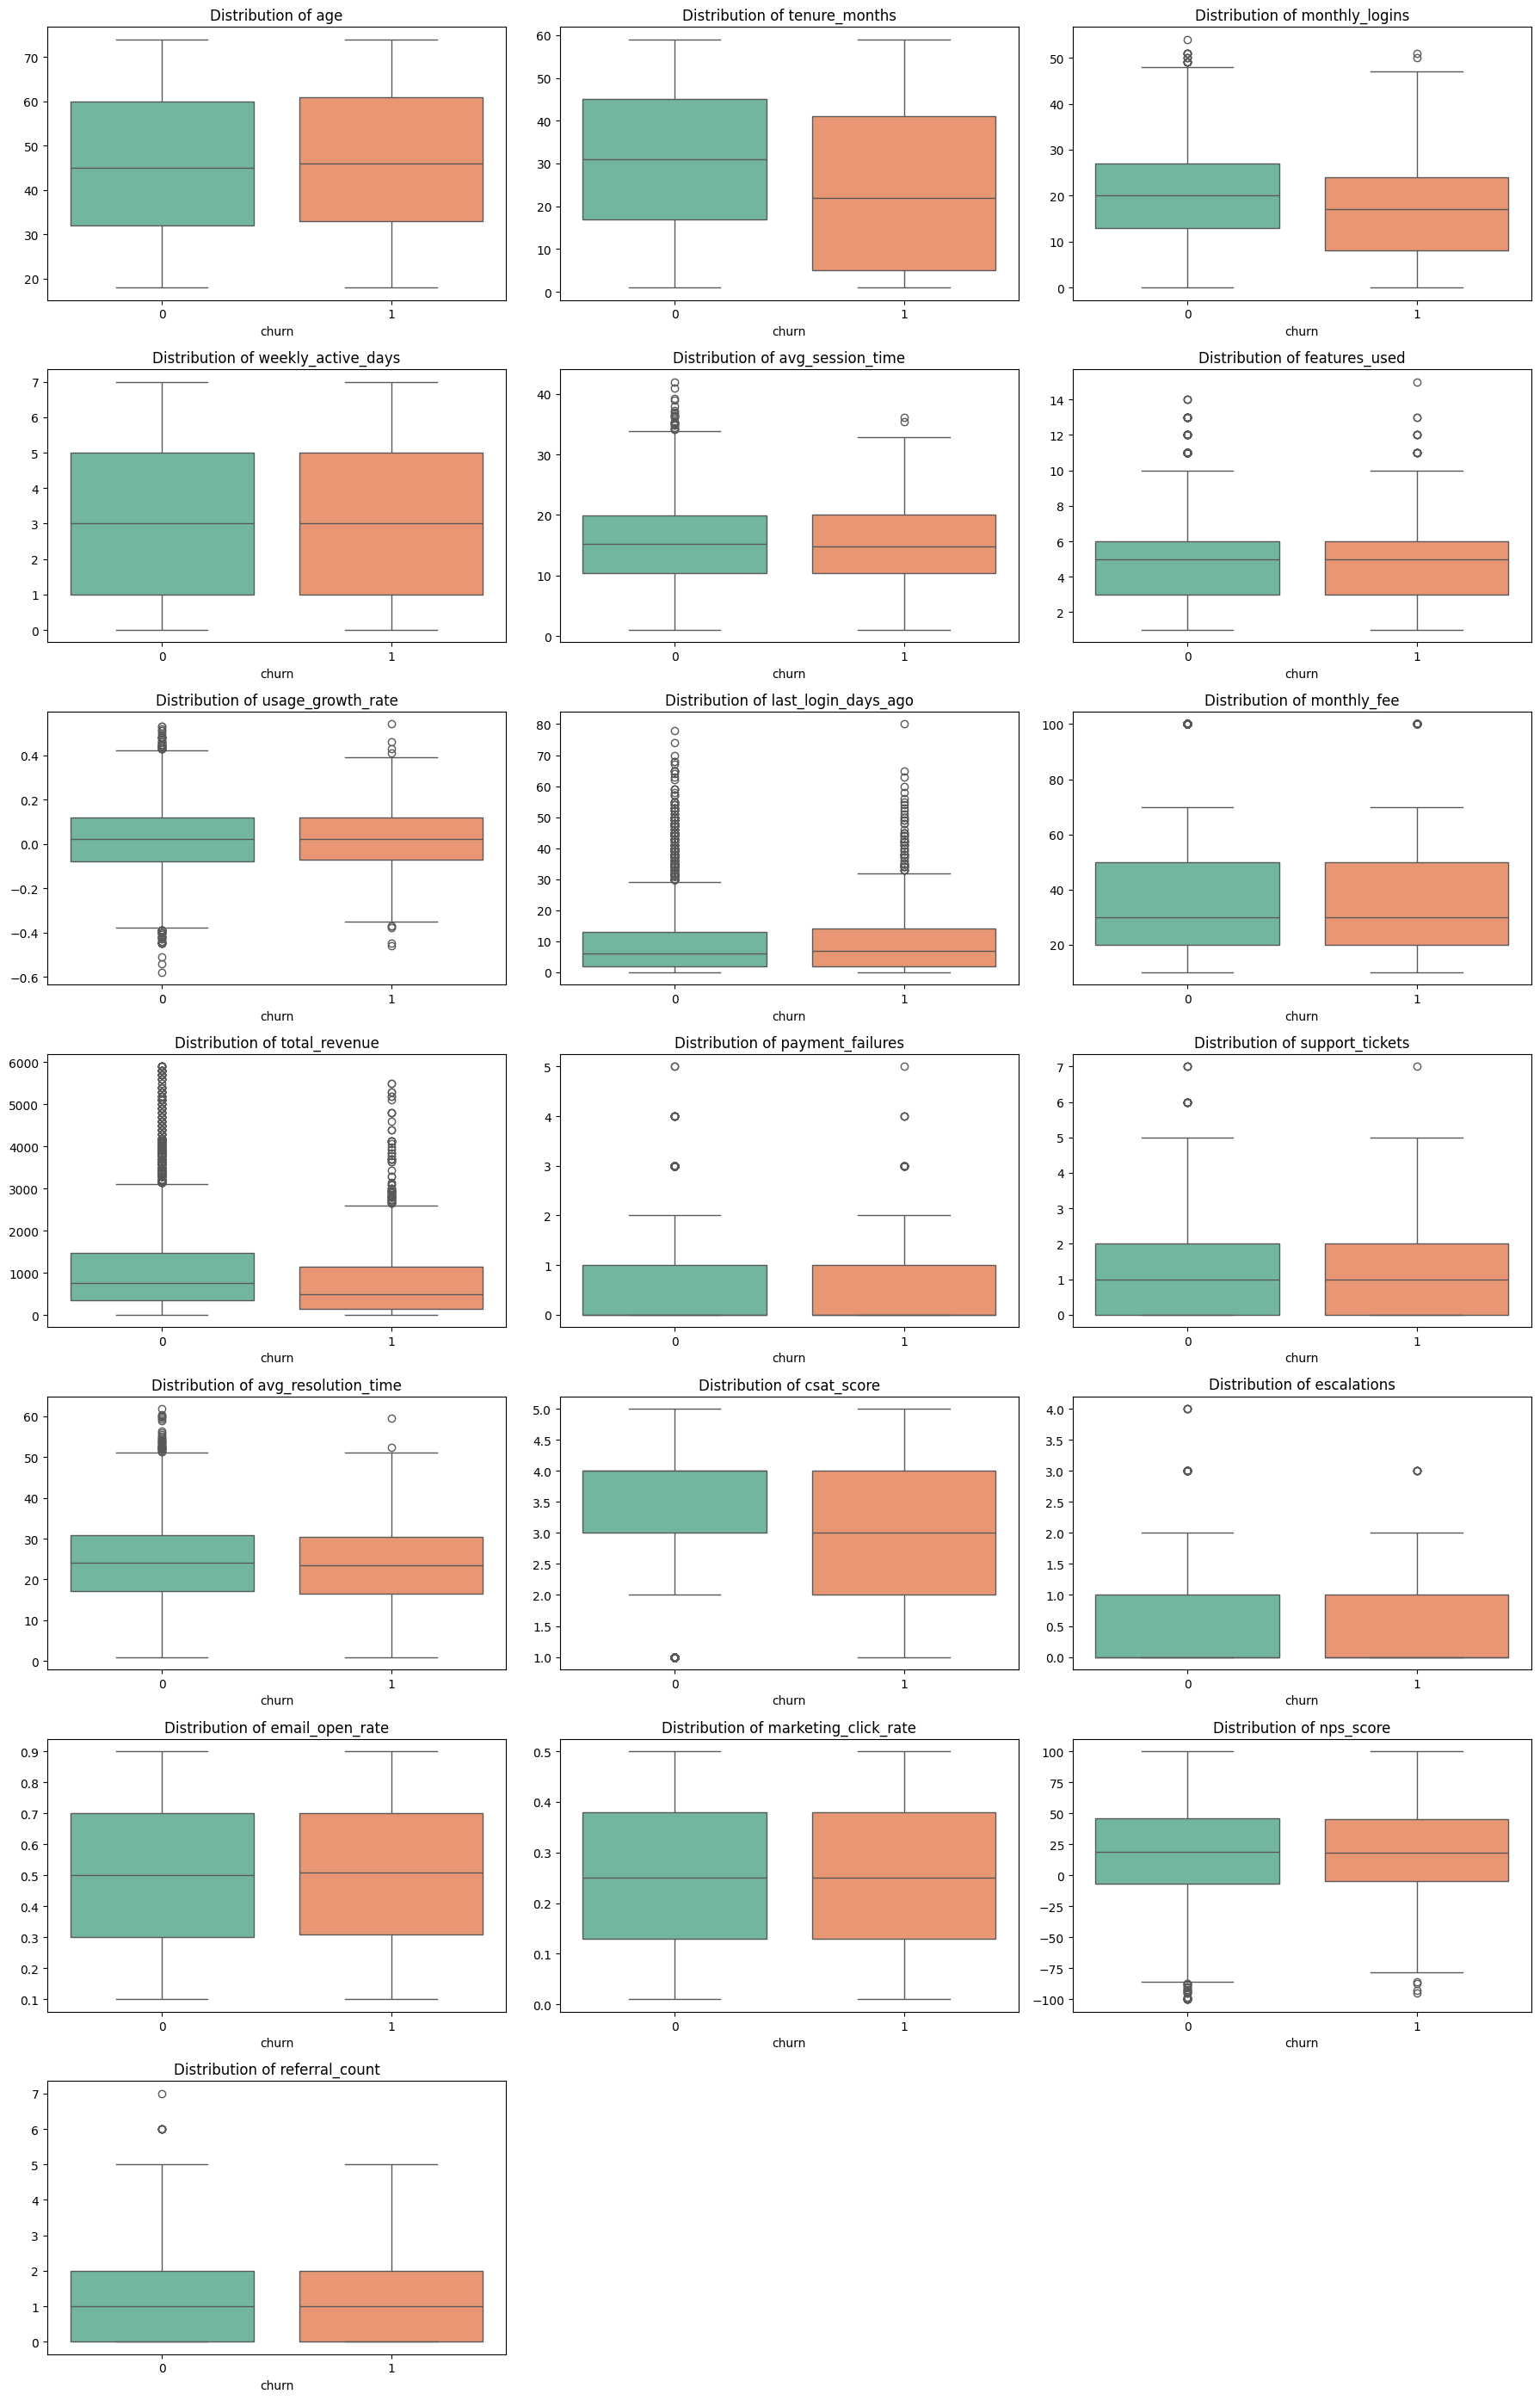

In [90]:
# Display box plots of numerical features in subplots of 3 columns before removal of outliers
numerical_columns = ['age','tenure_months','monthly_logins','weekly_active_days','avg_session_time','features_used',
                     'usage_growth_rate','last_login_days_ago','monthly_fee','total_revenue','payment_failures',
                     'support_tickets','avg_resolution_time','csat_score','escalations','email_open_rate',
                     'marketing_click_rate','nps_score','referral_count']
n_features = len(numerical_columns)
n_cols = 3
n_rows = math.ceil(n_features/n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*4))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.boxplot(x=df['churn'], y=df[col], ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_ylabel('')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Outliers**     
Outliers are removed from numeric features using interquartile range (**IQR**) rule.

In [91]:
# Removal of outliers from numeric features using IQR
outliers_numeric_list = ['age','tenure_months','monthly_logins','weekly_active_days','avg_session_time','features_used',
                         'usage_growth_rate','last_login_days_ago','monthly_fee','total_revenue','payment_failures',
                         'support_tickets','avg_resolution_time','csat_score','escalations','email_open_rate',
                         'marketing_click_rate','nps_score','referral_count']

for col in outliers_numeric_list:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [92]:
# Verify the reduction of data rows with the removal of numeric outliers
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7937 entries, 0 to 9999
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   gender                  7937 non-null   object 
 1   age                     7937 non-null   int64  
 2   country                 7937 non-null   object 
 3   city                    7937 non-null   object 
 4   customer_segment        7937 non-null   object 
 5   tenure_months           7937 non-null   int64  
 6   signup_channel          7937 non-null   object 
 7   contract_type           7937 non-null   object 
 8   monthly_logins          7937 non-null   int64  
 9   weekly_active_days      7937 non-null   int64  
 10  avg_session_time        7937 non-null   float64
 11  features_used           7937 non-null   int64  
 12  usage_growth_rate       7937 non-null   float64
 13  last_login_days_ago     7937 non-null   int64  
 14  monthly_fee             7937 non-null   int64

**Box Plots of numerical features after removal of outliers**     
When the churn median line is lower than the no churn median line, churn is more likely. For example, the lower values of the following features indicate likelihood of churn:     
**tenure_months**, **monthly_logins**, **weekly_active_days**, **avg_session_time**, **total_revenue**, **csat_score**, **marketing_click_rate**, **nps_score**      
The taller churn boxes in tenure months and csat mean more variability; the short boxes mean that the customers are similar to each other.
The points beyond the whiskers are outliers. These remaining outliers may be allowed to remain to conserve data.
Overlapping churn and no churn boxes indicate that the feature might not be a good predictor. Separation of these churn and no churn boxes would be a strong signal for good predictors like tenure months, monthly logins, total revenue and csat score.

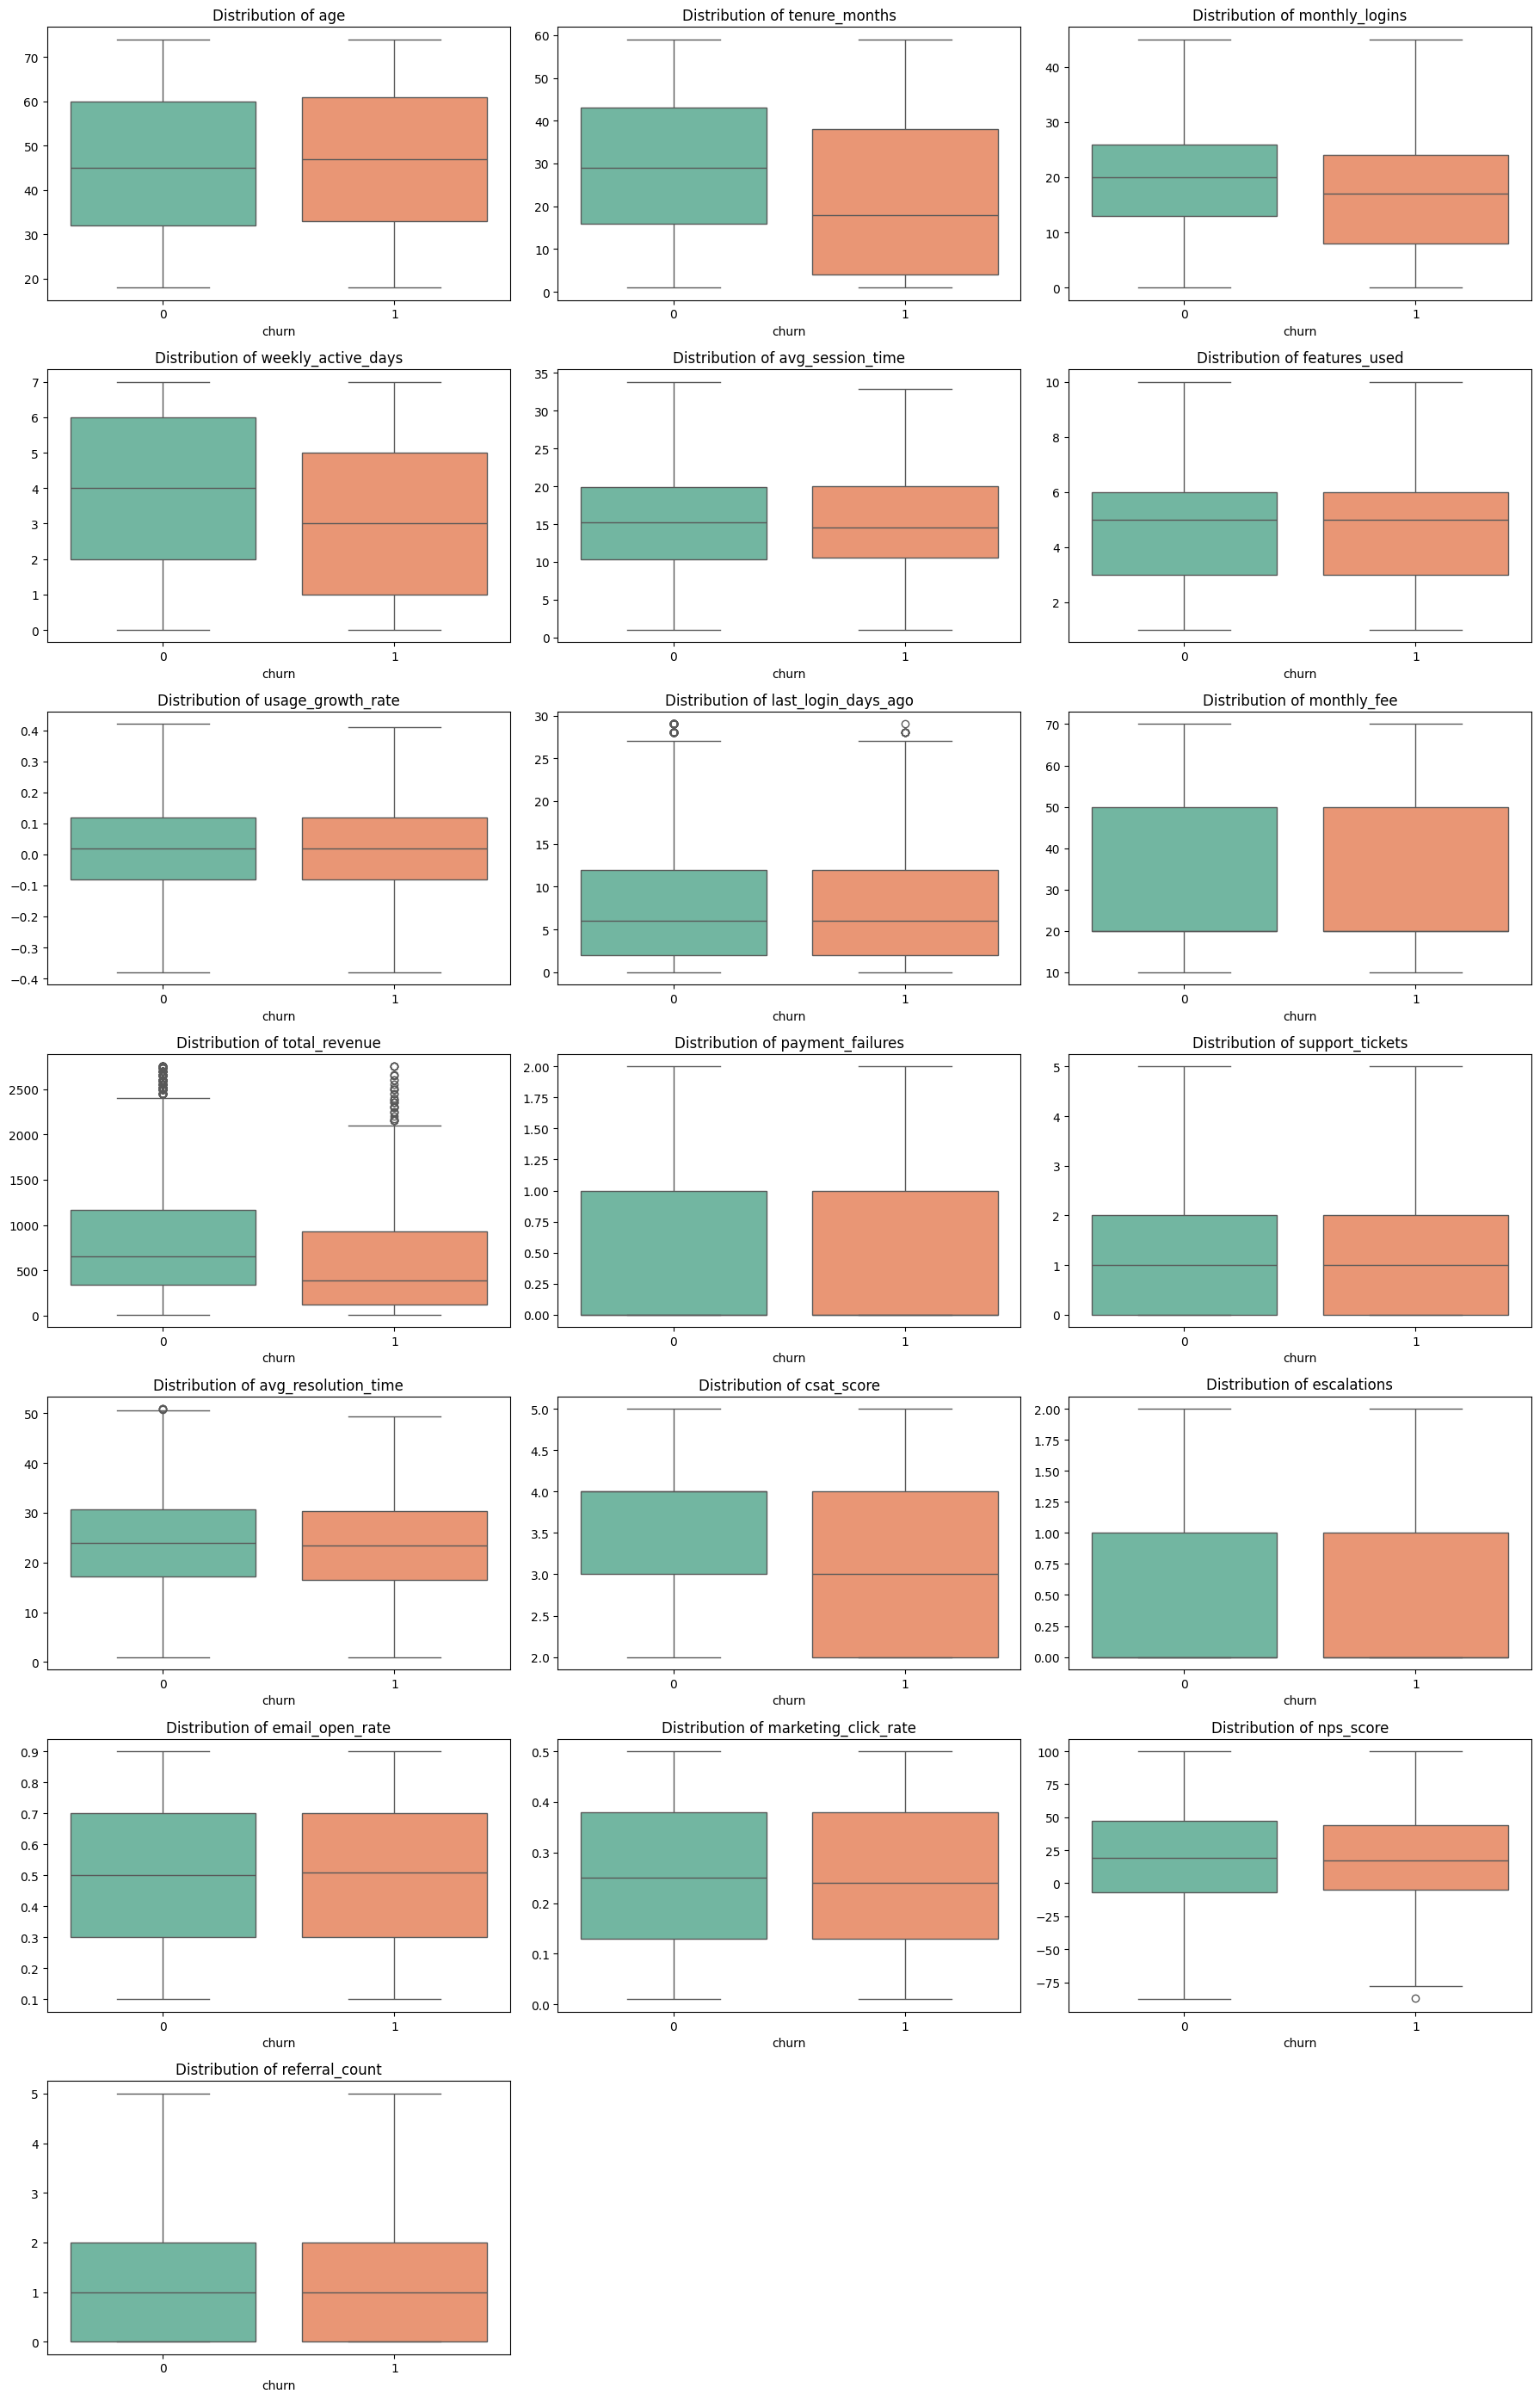

In [93]:
# Re-display box plots of numerical features after removal of outliers
numerical_columns = ['age','tenure_months','monthly_logins','weekly_active_days','avg_session_time','features_used',
                     'usage_growth_rate','last_login_days_ago','monthly_fee','total_revenue','payment_failures',
                     'support_tickets','avg_resolution_time','csat_score','escalations','email_open_rate',
                     'marketing_click_rate','nps_score','referral_count']

n_features = len(numerical_columns)
n_cols = 3
n_rows = math.ceil(n_features/n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*4))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.boxplot(x=df['churn'], y=df[col], ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_ylabel('')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [94]:
# Display features medians of no churn (0) and churn (1)
medians = df.groupby('churn')[['age','tenure_months','monthly_logins','weekly_active_days','avg_session_time','features_used',
                               'usage_growth_rate','last_login_days_ago','monthly_fee','total_revenue','payment_failures',
                               'support_tickets','avg_resolution_time','csat_score','escalations','email_open_rate',
                               'marketing_click_rate','nps_score','referral_count']].median().T
medians

churn,0,1
age,45.000000,47.000000
tenure_months,29.000000,18.000000
monthly_logins,20.000000,17.000000
weekly_active_days,4.000000,3.000000
avg_session_time,15.179032,14.549000
features_used,5.000000,5.000000
usage_growth_rate,0.020000,0.020000
last_login_days_ago,6.000000,6.000000
monthly_fee,20.000000,20.000000
total_revenue,650.000000,390.000000


**Stacked Bars of categorical features (in percentages)**     
Based on the color ratios of the stacked bars: **males** have slightly more churn; the higher churns are in **Germany**, **UK**, **Australia** and **USA**; **New York**, **Dhaka** and **Toronto** are slightly ahead in churns; **SME**, **Referral**, **Quarterly/Monthly** and **Card** are slightly ahead in churns as well; the following are also slightly ahead: **no discount applied**, **no price increase last 3m** and **technical/billing** complaint type. **Unsatisfied** survey response is way ahead in churns. **Yearly** has lower churn than either **Monthly** or **Quarterly**.

In [95]:
# Define a function to plot stacked bars with annotated percentages of churn status
def plot_stacked_bars(df, features, target='churn', n_cols=3):
    n_features = len(features)
    n_rows = math.ceil(n_features / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*5))
    axes_flat = axes.flatten()

    for i, col in enumerate(features):
        ax = axes_flat[i]
        cross_tab = pd.crosstab(df[col], df[target], normalize='index')
        cross_tab.plot(kind='barh', stacked=True, ax=ax, color=['#7294ac','#81c79d'], legend=False)
        for p in ax.patches:
            width = p.get_width()
            if width > 0.05:
                x_pos = p.get_x() + width / 2
                y_pos = p.get_y() + p.get_height() / 2
                ax.text(x_pos, y_pos, f'{width*100:.1f}%',
                        va='center', ha='center',
                        color='white', fontweight='bold', fontsize=11)
        ax.set_title(f'Churn Distribution: {col}', fontsize=14)
        ax.set_xlabel('Proportion')
        ax.set_ylabel('')

    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02),
                ncol=2, title=f'{target.capitalize()} Status', fontsize=12)

    for j in range(i+1, len(axes_flat)):
        fig.delaxes(axes_flat[j])

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

In [96]:
# Review the churn distribution
churn_dist = df['churn'].value_counts(normalize=True)

print(churn_dist)

churn
0    0.906262
1    0.093738
Name: proportion, dtype: float64


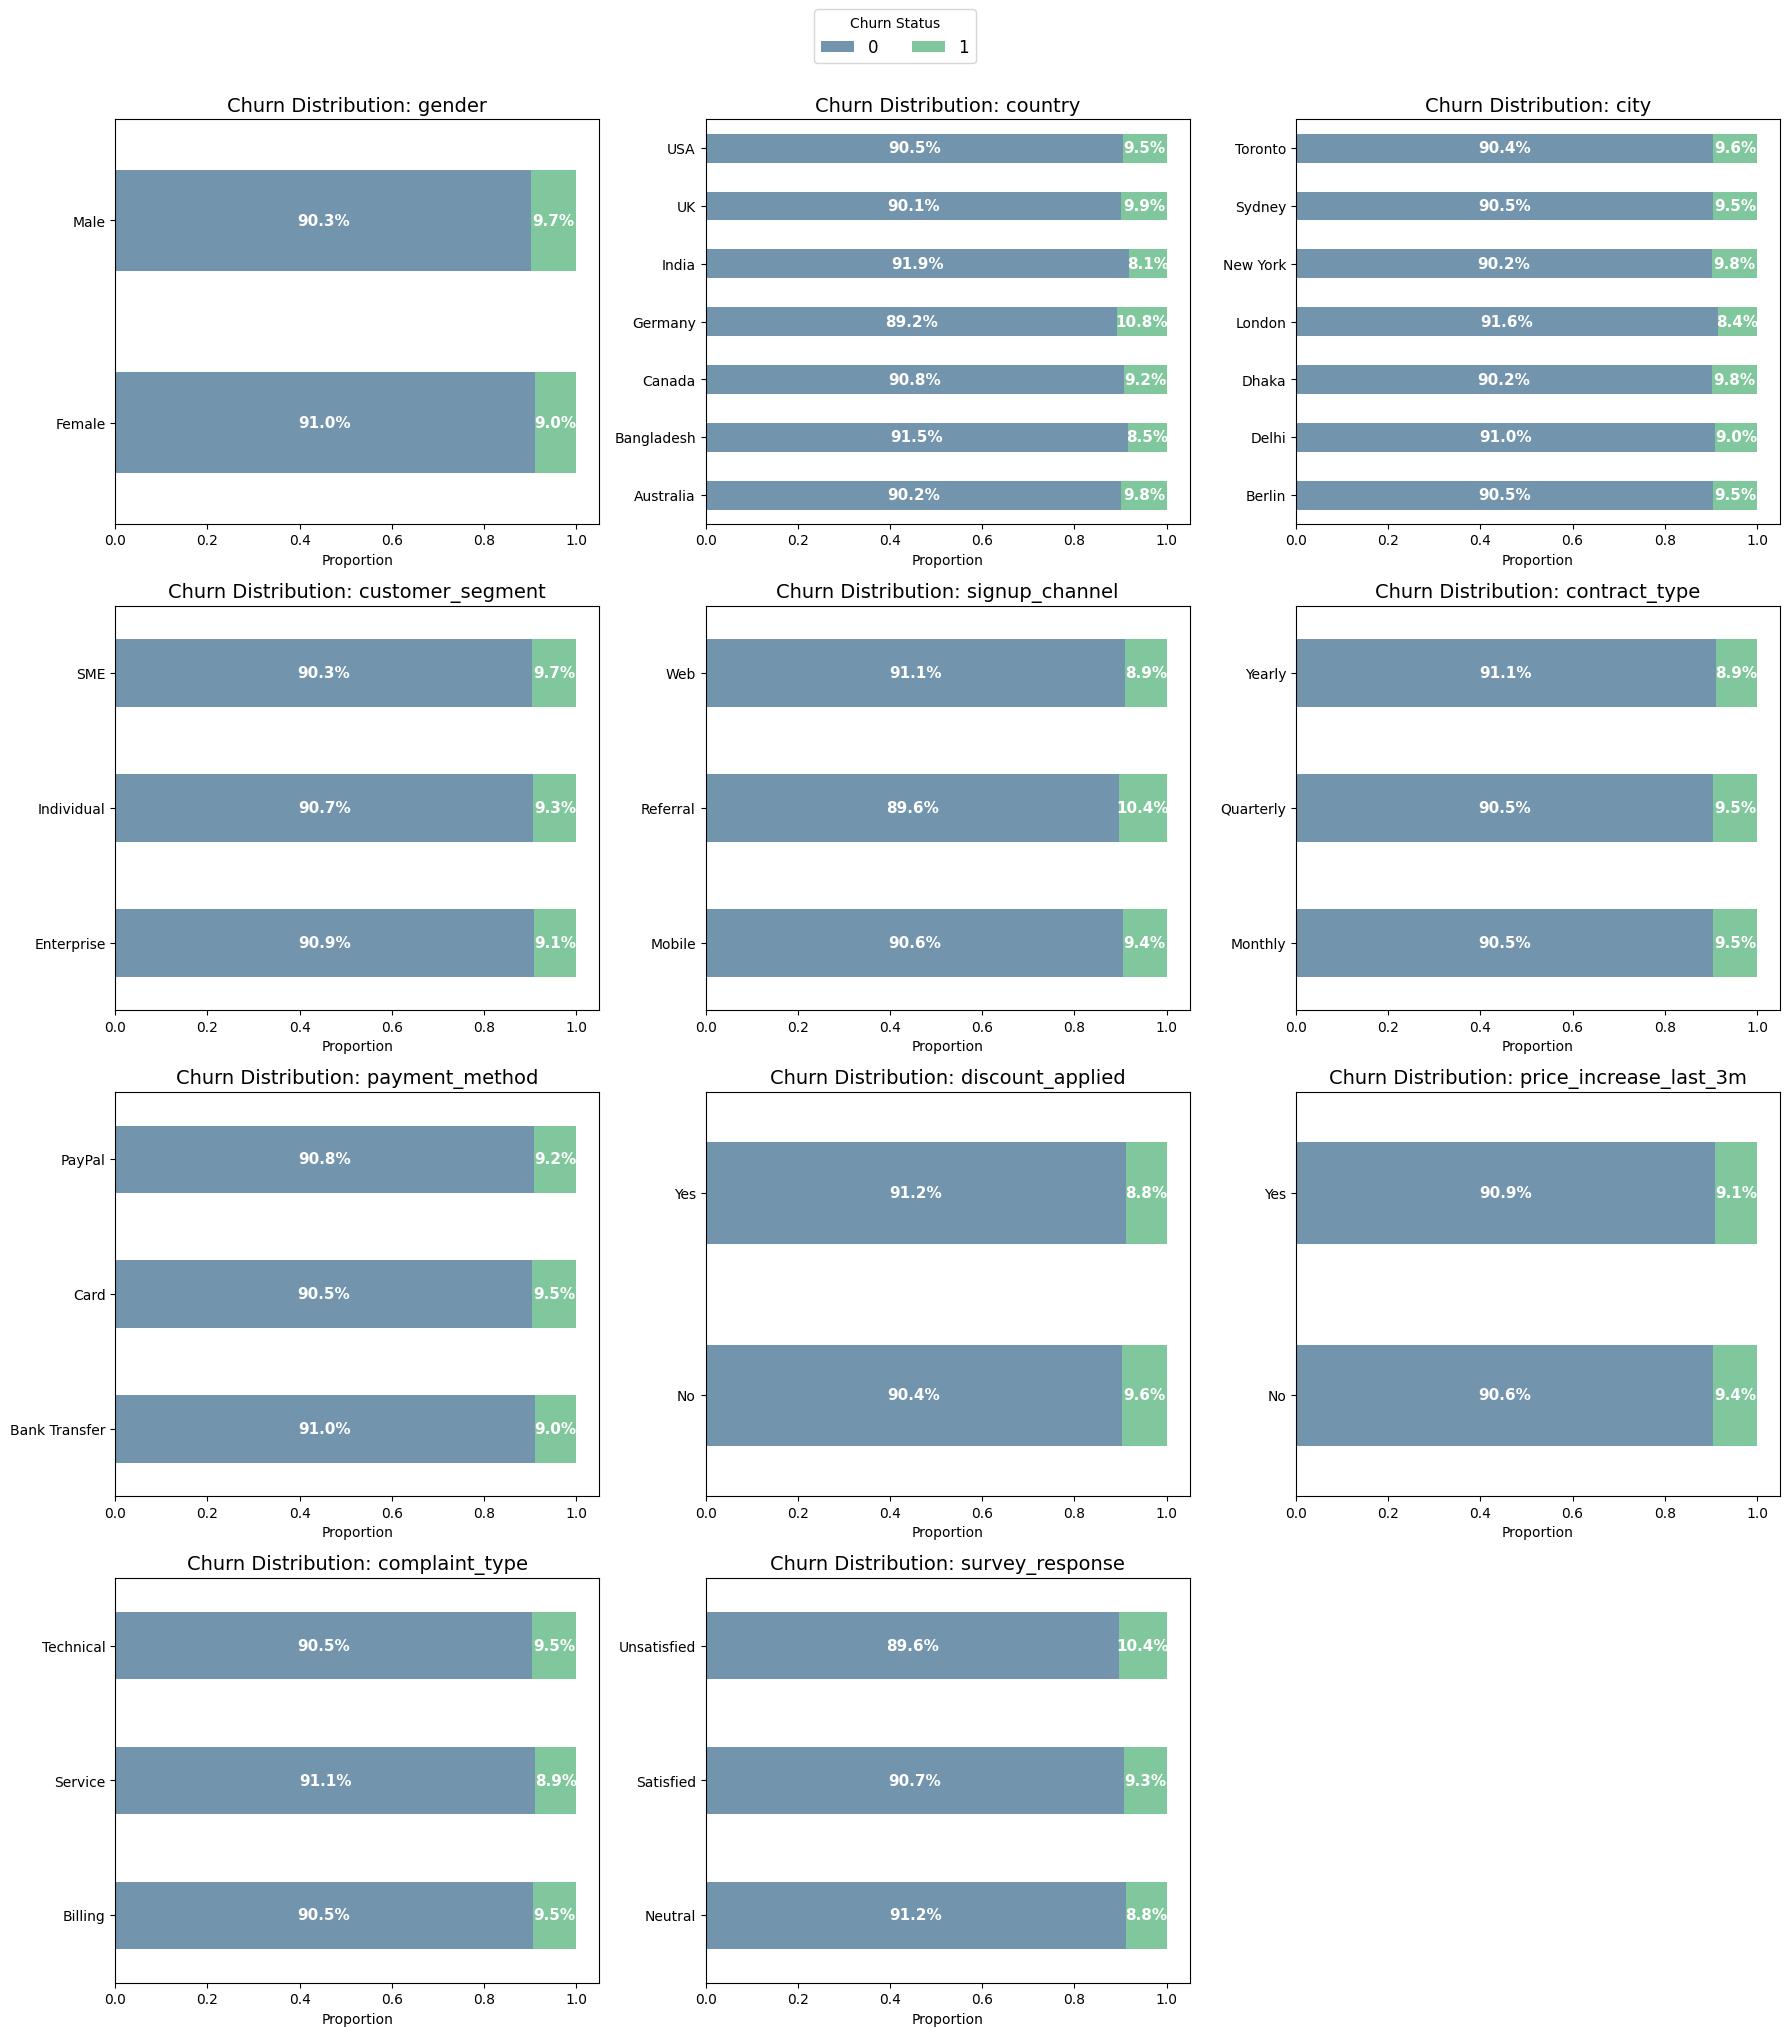

In [97]:
# Run the plot function on categorical columns
categorical_columns = ['gender', 'country', 'city', 'customer_segment', 'signup_channel', 'contract_type', 'payment_method',
                       'discount_applied','price_increase_last_3m', 'complaint_type', 'survey_response']

plot_stacked_bars(df, categorical_columns)

**HISTOGRAMS**     
**Age** - roughly uniform distribution between ages 18 - 74 years old     
**Tenure months** - roughly uniform distribution over 60 months, there are slightly less users with low tenure (newer customers are a churn risk)     
**Monthly logins** - right skewed distribution, most users login 10-25 times a month (low login frequency is a churn warning signal)    
**Weekly active days** - fairly evenly distributed (users active less than 2 days a week are likely churn risks)     
**Avg session time** - roughly normal distribution, most users spend a moderate amount of time, very short sessions may signal disengagement     
**Features used** - right skewed distribution, most users use around 3-7 features, feature usage correlates with higher retention     
**Usage growth rate** - approximately normal distribution, centered at 0 (negative values indicate declining engagement and higher churn risk and while positive values show growing engagement and lower churn risk)     
**Last login days ago** - strong right skew, most customers logged in recently and there is a long tail of inactive users (30-80 days) (more days would signal higher churn probability)     
**Monthly fee** - discrete spikes are pricing tiers and most are on the low side     
**Total revenue** - right skewed, there are many low-lifetime-value customers and few high-value, long-tenure customers     
**Payment failures** - most customers pay and there is a small group that fail to pay, failures often precede involuntary churn     
**Support tickets** - majority have 0-1 ticket and few customers have many issues, more tickets would lead to friction or dissatisfaction     
**Avg resolution time** - roughly normal distribution, typical resolution is 20-30 units of time (slow support would drive churn even if issues are       resolved)             
**Csat score** - most customers rate 3-4 (1-2 are danger zones), the coefficient would be negative - higher satisfaction means lower churn     
**Escalations** - majority of customers never escalate but a small group escalates multiple times (escalations indicate failed experiences and are very predictive of churn)     
**Email open rate** - distribution is fairly uniform, both low engagement and high engagement users exist (low open rate would reveal disengagement and result to higher churn risk while high open rate means engagement customers and lower churn)     
**Marketing click rate** - roughly uniform although slightly sparse at the extremes (clicking is a stronger engagement signal than opening)     
**Nps score** - bell shaped distribution, healthy mix of detractors (much more likely to churn), passives and promoters (highly retained)     
**Referral count** - strong right skew, mostly at 0-1, the coefficient for this feature would be strong and negative (customers with 2+ referrals are very unlikely to churn)     
**Churn** - most customers stay and a minority churn, need to catch churners early by focusing on a good balance of recall and precision

In [98]:
# Define a function to plot histograms for numeric columns
def plot_grid_histograms(df, column_list, main_title='Numeric Features Distribution Analysis'):
    fig, axes = plt.subplots(nrows=7, ncols=3, figsize=(15,25))
    fig.suptitle(main_title, fontsize=18, fontweight='bold', y=0.98)
    axes = axes.flatten()
    for i, col_name in enumerate(column_list):
        ax = axes[i]
        sns.histplot(df[col_name], kde=True, ax=ax)
        col_mean = df[col_name].mean()
        col_median = df[col_name].median()
        ax.axvline(col_mean, color='red', linestyle='--', label='Mean')
        ax.axvline(col_median, color='green', linestyle='-', label='Median')
        ax.set_title(f'Distribution of {col_name}', fontsize=12, pad=10)
        ax.set_xlabel('Value Range', fontsize=10)
        ax.set_ylabel('Frequency', fontsize=10)
        ax.legend(fontsize=8)
    for j in range(i+1, len(axes)):
        axes[j].set_axis_off()
    plt.tight_layout(rect=[0,0.03,1,0.97])
    plt.show()

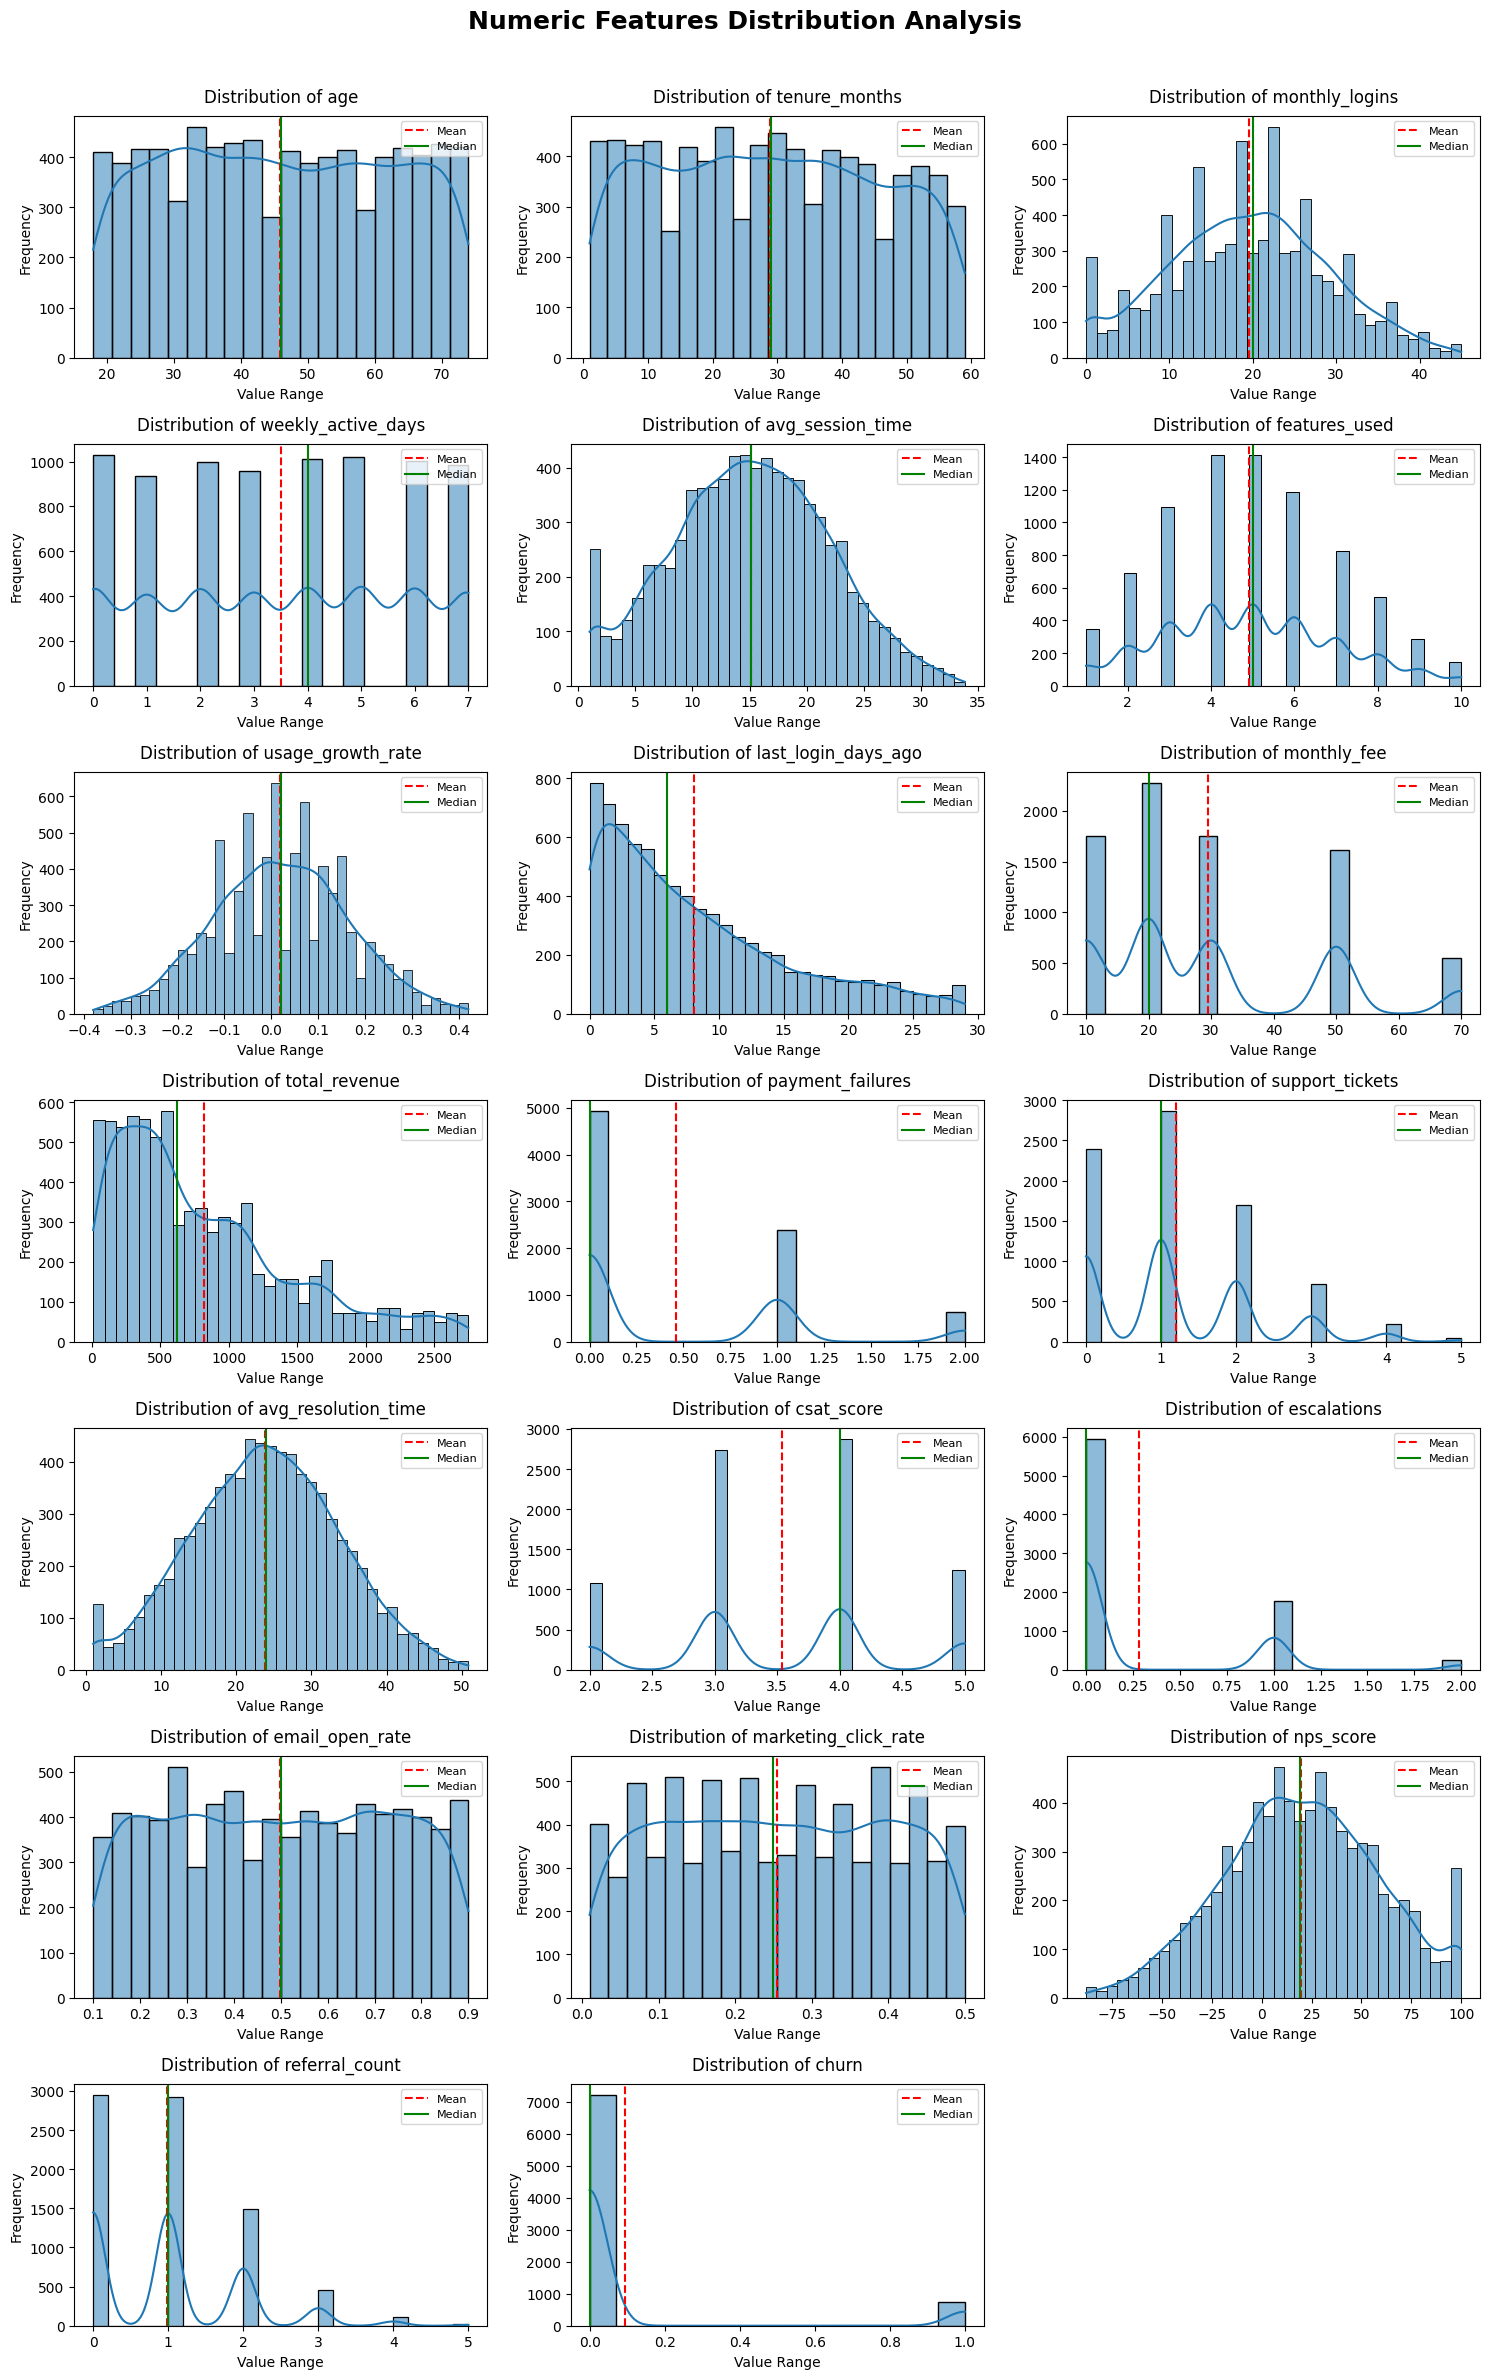

In [99]:
# Plot the histograms for numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

plot_grid_histograms(df, numeric_cols)

In [100]:
# List the numeric columns for the heat map
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
numeric_cols

['age',
 'tenure_months',
 'monthly_logins',
 'weekly_active_days',
 'avg_session_time',
 'features_used',
 'usage_growth_rate',
 'last_login_days_ago',
 'monthly_fee',
 'total_revenue',
 'payment_failures',
 'support_tickets',
 'avg_resolution_time',
 'csat_score',
 'escalations',
 'email_open_rate',
 'marketing_click_rate',
 'nps_score',
 'referral_count',
 'churn']

**HEAT MAP of numeric features**     
For readability, the significant correlations are highlighted in the heat map following the first heat map.

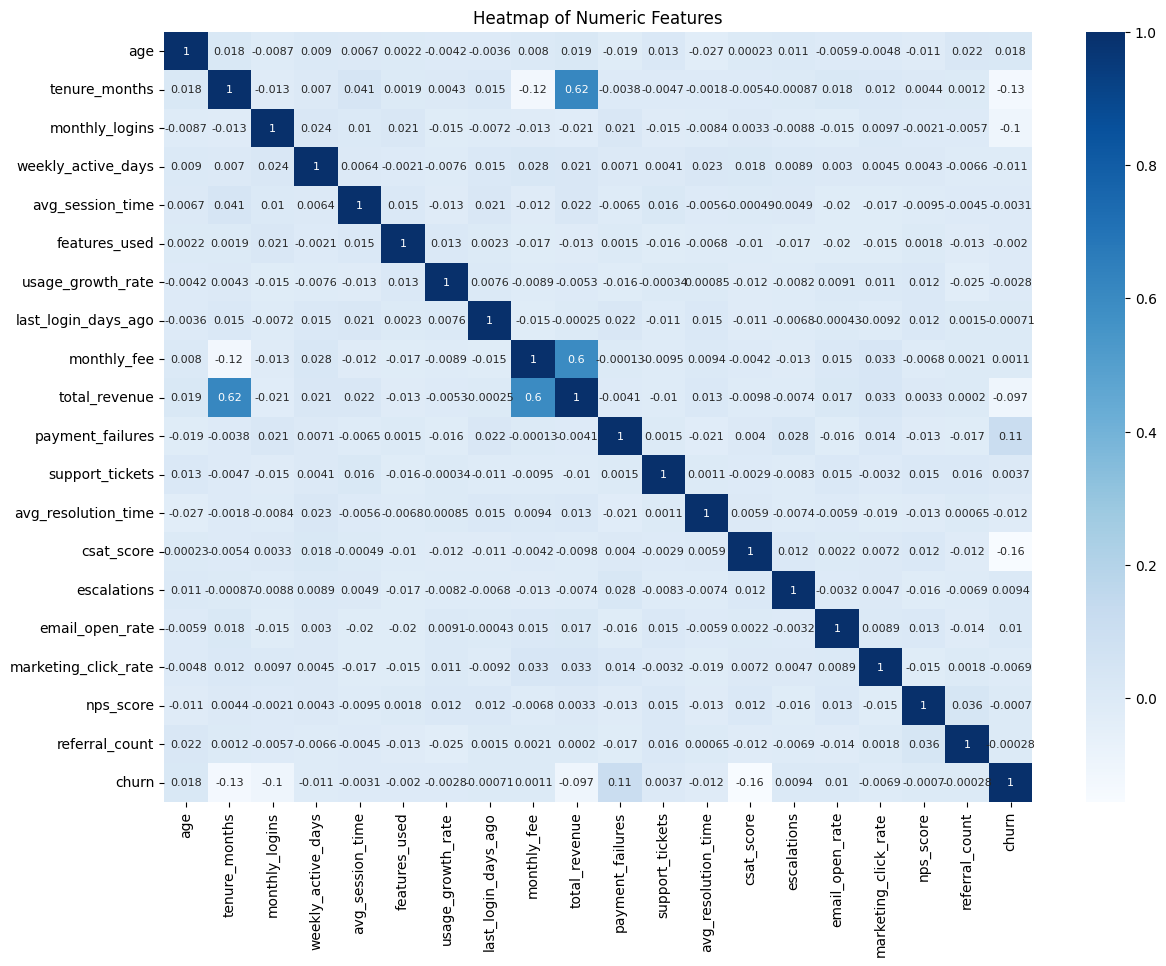

In [101]:
# Display the heat map of numeric features
df_numeric = df[numeric_cols]
plt.figure(figsize=(14,10))
ax = sns.heatmap(
    df_numeric.corr(),
    annot=True,
    cmap='Blues',
    annot_kws={"size": 8});
plt.title(f'Heatmap of Numeric Features')
plt.show()

**HEAT MAP highlighting significant correlations with 'churn'**     
Five (5) features are observed to have significant correlations with 'churn' as follows:
**payment_failures** (0.11) has a positive correlation with 'churn'(the more of these features, the more likely is the churn)

**tenure_months** (-0.13), **monthly_logins** (-0.10), **total_revenue** (-0.10), **csat_score** (-0.16) have a negative correlations with 'churn' (the more of these features, the less likely is the churn)     

Also, **total_revenue** is positively correlated with **tenure_months** (0.62) and **monthly_fee** (0.60).

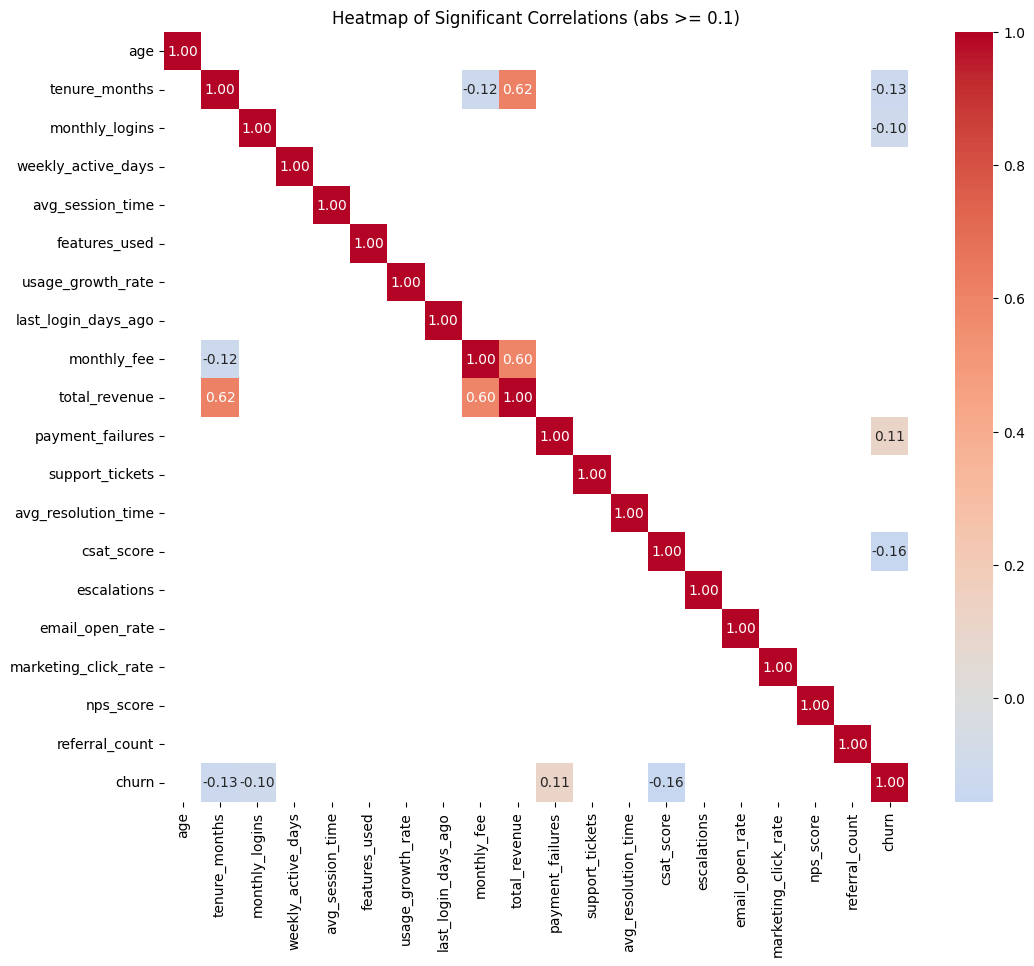

In [102]:
# Display heat map highlighting correlations >= threshold
corr_matrix = df_numeric.corr()
threshold = 0.1
sig_corr = corr_matrix[(corr_matrix.abs() >= threshold)]
plt.figure(figsize=(12,10))
sns.heatmap(sig_corr, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title(f'Heatmap of Significant Correlations (abs >= {threshold})')
plt.show()

**Feature Engineering**     
**total_revenue** is positively correlated with **tenure_months** (0.62) and **monthly_fee** (0.60) which is considered high.     
**total_revenue** does not add new predictive signal beyond **tenure_months** and **monthly_fee** because **total_revenue** is the product of **tenure_months** and **monthly_fee**. This means that **total_revenue** is mostly redundant.
There is an opportunity here for feature engineering.

In [103]:
# Create new column to capture the interaction between monthly_fee and tenure_months
df["tenure_fee_interaction"] = df["tenure_months"] * df["monthly_fee"]

# Drop total_revenue which is mostly redundant
df = df.drop(columns=['total_revenue'])

In [104]:
# Verify info
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7937 entries, 0 to 9999
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   gender                  7937 non-null   object 
 1   age                     7937 non-null   int64  
 2   country                 7937 non-null   object 
 3   city                    7937 non-null   object 
 4   customer_segment        7937 non-null   object 
 5   tenure_months           7937 non-null   int64  
 6   signup_channel          7937 non-null   object 
 7   contract_type           7937 non-null   object 
 8   monthly_logins          7937 non-null   int64  
 9   weekly_active_days      7937 non-null   int64  
 10  avg_session_time        7937 non-null   float64
 11  features_used           7937 non-null   int64  
 12  usage_growth_rate       7937 non-null   float64
 13  last_login_days_ago     7937 non-null   int64  
 14  monthly_fee             7937 non-null   int64

In [105]:
# Select the top 7 features for the pair plot analysis including 'churn'
corr = df.corr(numeric_only=True)['churn'].abs().sort_values(ascending=False)
top_features = corr.head(7).index.tolist()
top_features

['churn',
 'csat_score',
 'tenure_months',
 'payment_failures',
 'monthly_logins',
 'tenure_fee_interaction',
 'age']

**PAIR PLOT Analysis**     
**Csat score** - **diagonal** - churns are concentrated at lower scores (1-2) while non-churns dominate at higher scores (4-5). vs **Tenure months** - long tenure customers tend to have higher Csat score, churners with long tenure usually have lower Csat than non-churners. vs **Payment failures** - customers with payment failures have low Csat scores. vs **Monthly logins** - customers with fewer monthly logins churn, most who churned scored 2. vs **tenure_fee_interaction** - most who churned also scored 2. vs **last_login_days_ago** - most churners score 2 as well, at the low end of the last_login_days_ago distribution

**Tenure months** - **diagonal** - there are more churners at low tenure (new customers) but still present across all tenures. vs **Payment failures** - at payment failures of 3, churn is spread over the tenure months. vs **Monthly logins** - churn is present over the spead of tenure months with lower monthly logins and with lower tenure months, churn is present over the spread of monthly logins. vs **tenure_fee_interaction** - churn is fairly distributed although gravitating towards the low end of tenure fee interation. vs **last_login_days_ago** - churners are at the lower end of tenure months; churners at the high end of tenure months have low last_login_days_ago

**Payment failures** - **diagonal** - most customers have 0-1 failures but churn happens at 2+ failures. vs **Monthly logins** - churn happens at higher payment failures and lower monthly logins.  vs **tenure_fee_interaction** - high payment failures have more churn especially at lower tenure_fee_interactions. vs **last_login_days_ago** - churners are at payment failure 2 and mostly at low last_login_days_ago     

**Monthly logins** - **diagonal** - churners skew left (lower logins). vs **tenure_fee_interaction** - there is churn at low monthly logins and low tenure_fee_interations. vs **last_login_days_ago** - churners crowd the low end of monthly logins and last_login_days_ago

**tenure_fee_interaction** - **diagonal** - strong right skew, churners mostly at lower interaction. vs **last_login_days_ago** - while fairly distributed, churners gravitate towards low interaction

**last_login_days_ago** - **diagonal** - right skewed, churn is at the low end of the distribution


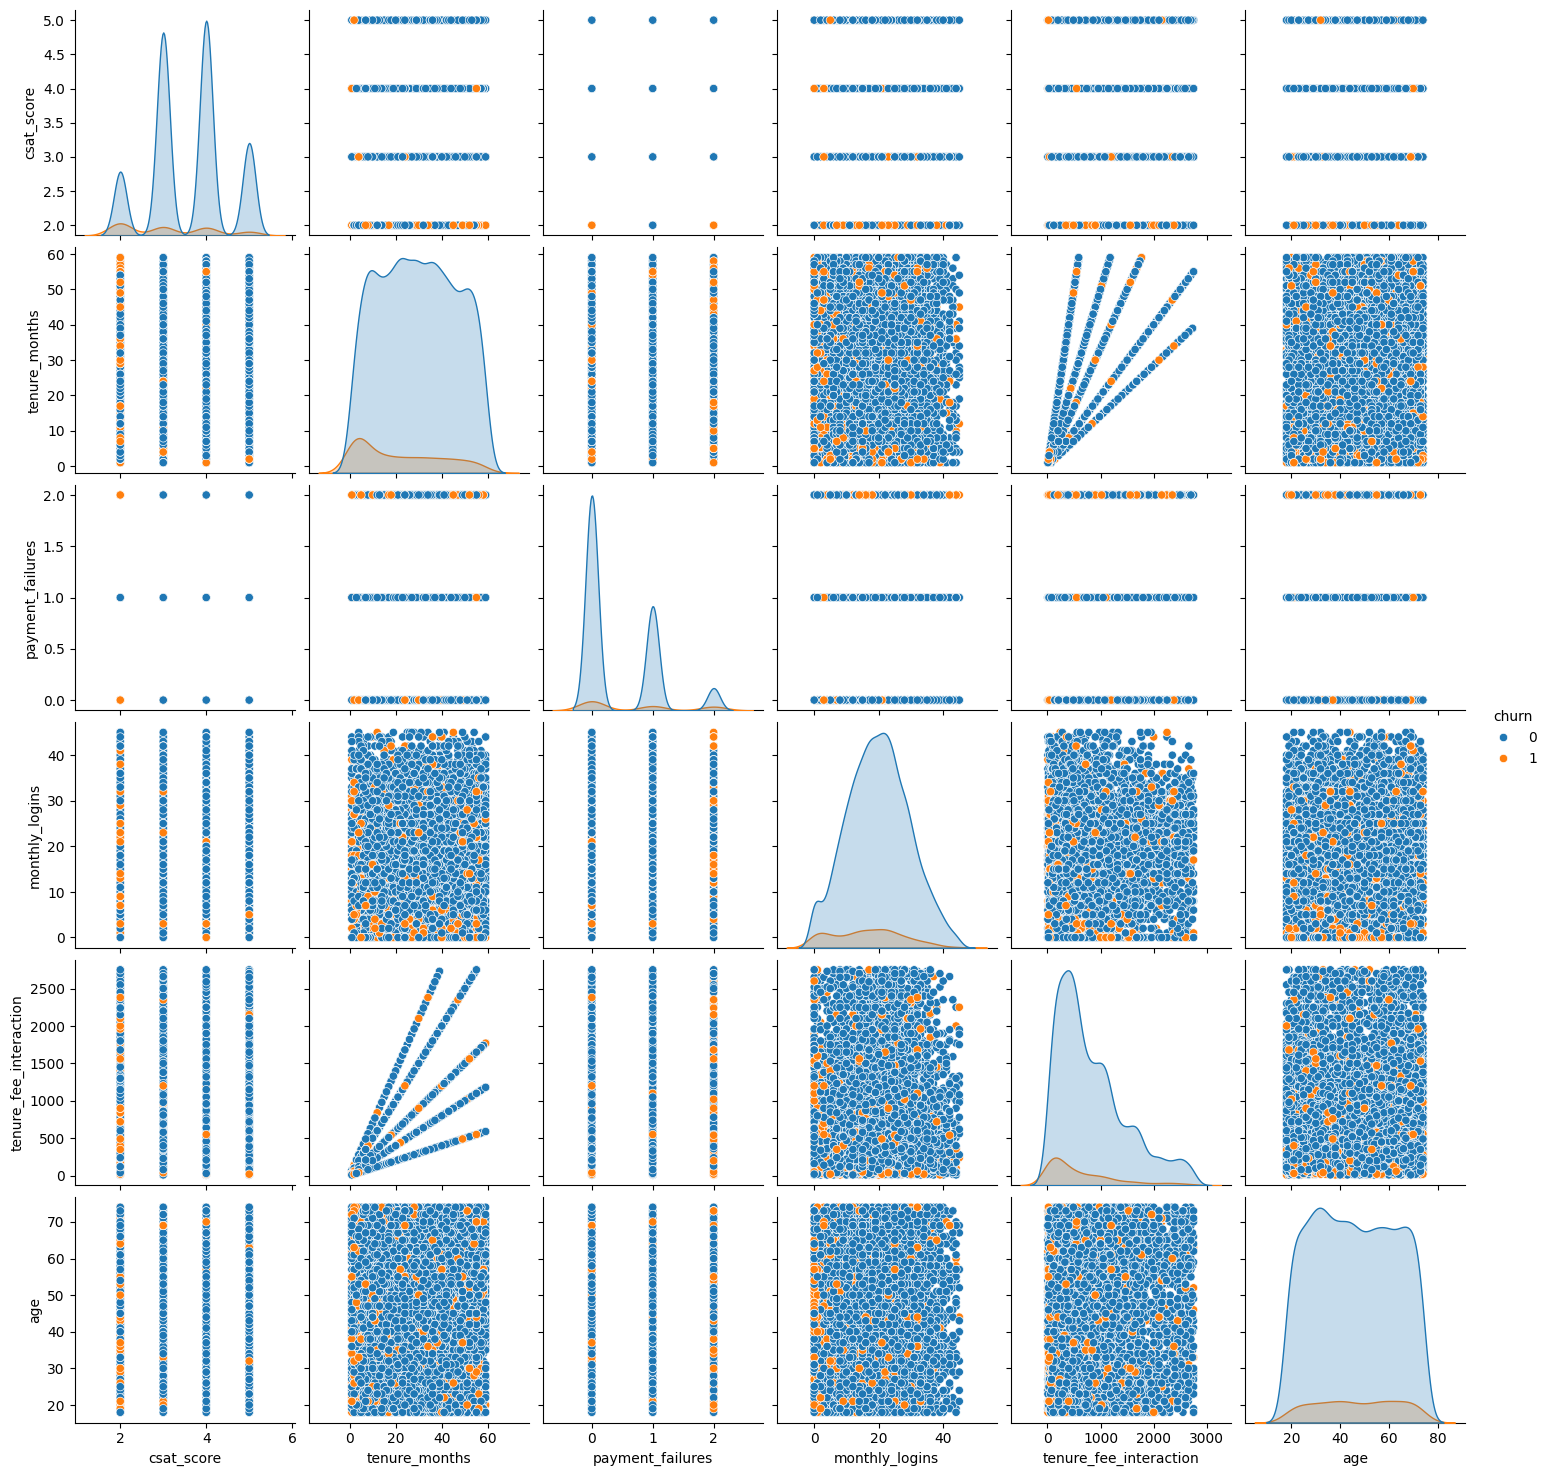

In [106]:
# Pair plot the top 6 numeric features with 'churn' in hue
sns.pairplot(df[top_features], hue='churn', diag_kind="kde")
plt.show()

In [107]:
# Verify info prior to modeling
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7937 entries, 0 to 9999
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   gender                  7937 non-null   object 
 1   age                     7937 non-null   int64  
 2   country                 7937 non-null   object 
 3   city                    7937 non-null   object 
 4   customer_segment        7937 non-null   object 
 5   tenure_months           7937 non-null   int64  
 6   signup_channel          7937 non-null   object 
 7   contract_type           7937 non-null   object 
 8   monthly_logins          7937 non-null   int64  
 9   weekly_active_days      7937 non-null   int64  
 10  avg_session_time        7937 non-null   float64
 11  features_used           7937 non-null   int64  
 12  usage_growth_rate       7937 non-null   float64
 13  last_login_days_ago     7937 non-null   int64  
 14  monthly_fee             7937 non-null   int64

In [108]:
# Save cleaned dataset
df.to_csv("sample_data/cleaned_data.csv", index=False)